# Analisis Exploratorio de Datos

In [1]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Configuración inicial
folder_csv = "../outphys_beta_0403"

file_pattern = f"{folder_csv}/*.csv"  # Ajusta a tu carpeta

chunksize = 10000
target_col = "branching_ratio_h2_gaga"


# Listar todos los archivos que cumplan con el patrón
files = glob.glob(file_pattern)
print("Número de archivos encontrados:", len(files))

Número de archivos encontrados: 1



--- Primer Pase: Cálculo de estadísticas globales ---
Procesando archivo: beta_explore.csv

Estadísticas globales del branching ratio:
  Valor mínimo: 5.650026055645731e-09
  Valor máximo: 0.0340440465475481
  Total de valores válidos: 16032
  Total de valores NaN: 0

--- Segundo Pase: Acumulando histograma ---


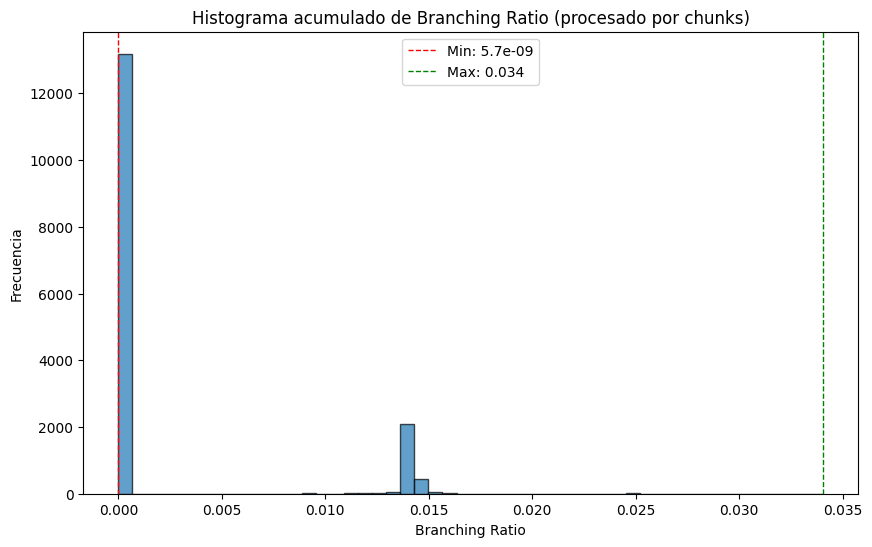

In [2]:


# Inicialización de variables para la estadística global
global_min = np.inf
global_max = -np.inf
total_valid = 0
total_nan = 0

# Primer pase: Procesar cada chunk para obtener el rango y contar NaNs
print("\n--- Primer Pase: Cálculo de estadísticas globales ---")
for f in files:
    print(f"Procesando archivo: {os.path.basename(f)}")
    try:
        for chunk in pd.read_csv(f, chunksize=chunksize):
            # Verificar que el chunk tenga la columna target
            if target_col not in chunk.columns:
                print(f"  - Advertencia: El archivo {f} no tiene la columna {target_col}. Se ignora este chunk.")
                continue

            # Reemplazar infinitos por NaN
            chunk.replace([np.inf, -np.inf], np.nan, inplace=True)

            # Contar los valores NaN en el branching ratio
            nan_count = chunk[target_col].isna().sum()
            total_nan += nan_count

            # Seleccionar los valores válidos
            valid = chunk[target_col].dropna()
            total_valid += len(valid)

            if not valid.empty:
                chunk_min = valid.min()
                chunk_max = valid.max()
                if chunk_min < global_min:
                    global_min = chunk_min
                if chunk_max > global_max:
                    global_max = chunk_max
    except Exception as e:
        print(f"Error al procesar {f}: {e}")

print("\nEstadísticas globales del branching ratio:")
print("  Valor mínimo:", global_min)
print("  Valor máximo:", global_max)
print("  Total de valores válidos:", total_valid)
print("  Total de valores NaN:", total_nan)

# Segundo pase: Calcular el histograma de los branching ratios usando el rango global
print("\n--- Segundo Pase: Acumulando histograma ---")
bins = 50
bin_edges = np.linspace(global_min, global_max, bins + 1)
hist_counts = np.zeros(bins)

for f in files:
    try:
        for chunk in pd.read_csv(f, chunksize=chunksize):
            if target_col not in chunk.columns:
                continue
            chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
            valid = chunk[target_col].dropna()
            if not valid.empty:
                counts, _ = np.histogram(valid, bins=bin_edges)
                hist_counts += counts
    except Exception as e:
        print(f"Error al procesar {f}: {e}")

# Graficar el histograma acumulado
plt.figure(figsize=(10, 6))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, hist_counts, width=(global_max - global_min) / bins, 
        edgecolor='k', alpha=0.7)
plt.xlabel("Branching Ratio")
plt.ylabel("Frecuencia")
plt.title("Histograma acumulado de Branching Ratio (procesado por chunks)")
plt.axvline(global_min, color='red', linestyle='dashed', linewidth=1, 
            label=f"Min: {global_min:.2g}")
plt.axvline(global_max, color='green', linestyle='dashed', linewidth=1, 
            label=f"Max: {global_max:.2g}")
plt.legend()
plt.show()


In [ ]:
param_cols = ['m_phi','mA','alpha','beta','lambda6','lambda7','m12']



--- Muestreo aleatorio mediante Reservoir Sampling ---
Muestra final para gráficos: 16032 registros.

Estadísticas globales del branching ratio:
  Valor mínimo: 5.650026055645731e-09
  Valor máximo: 0.0340440465475481
  Total de valores válidos: 16032


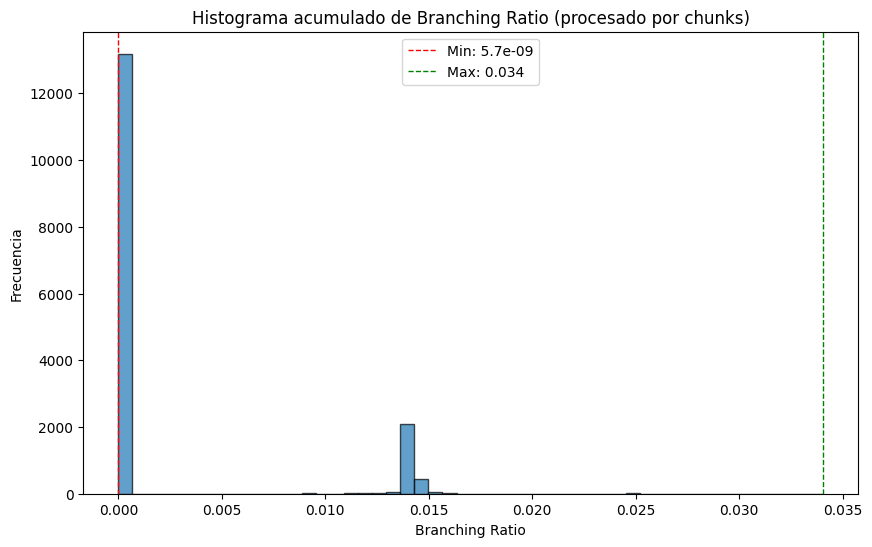

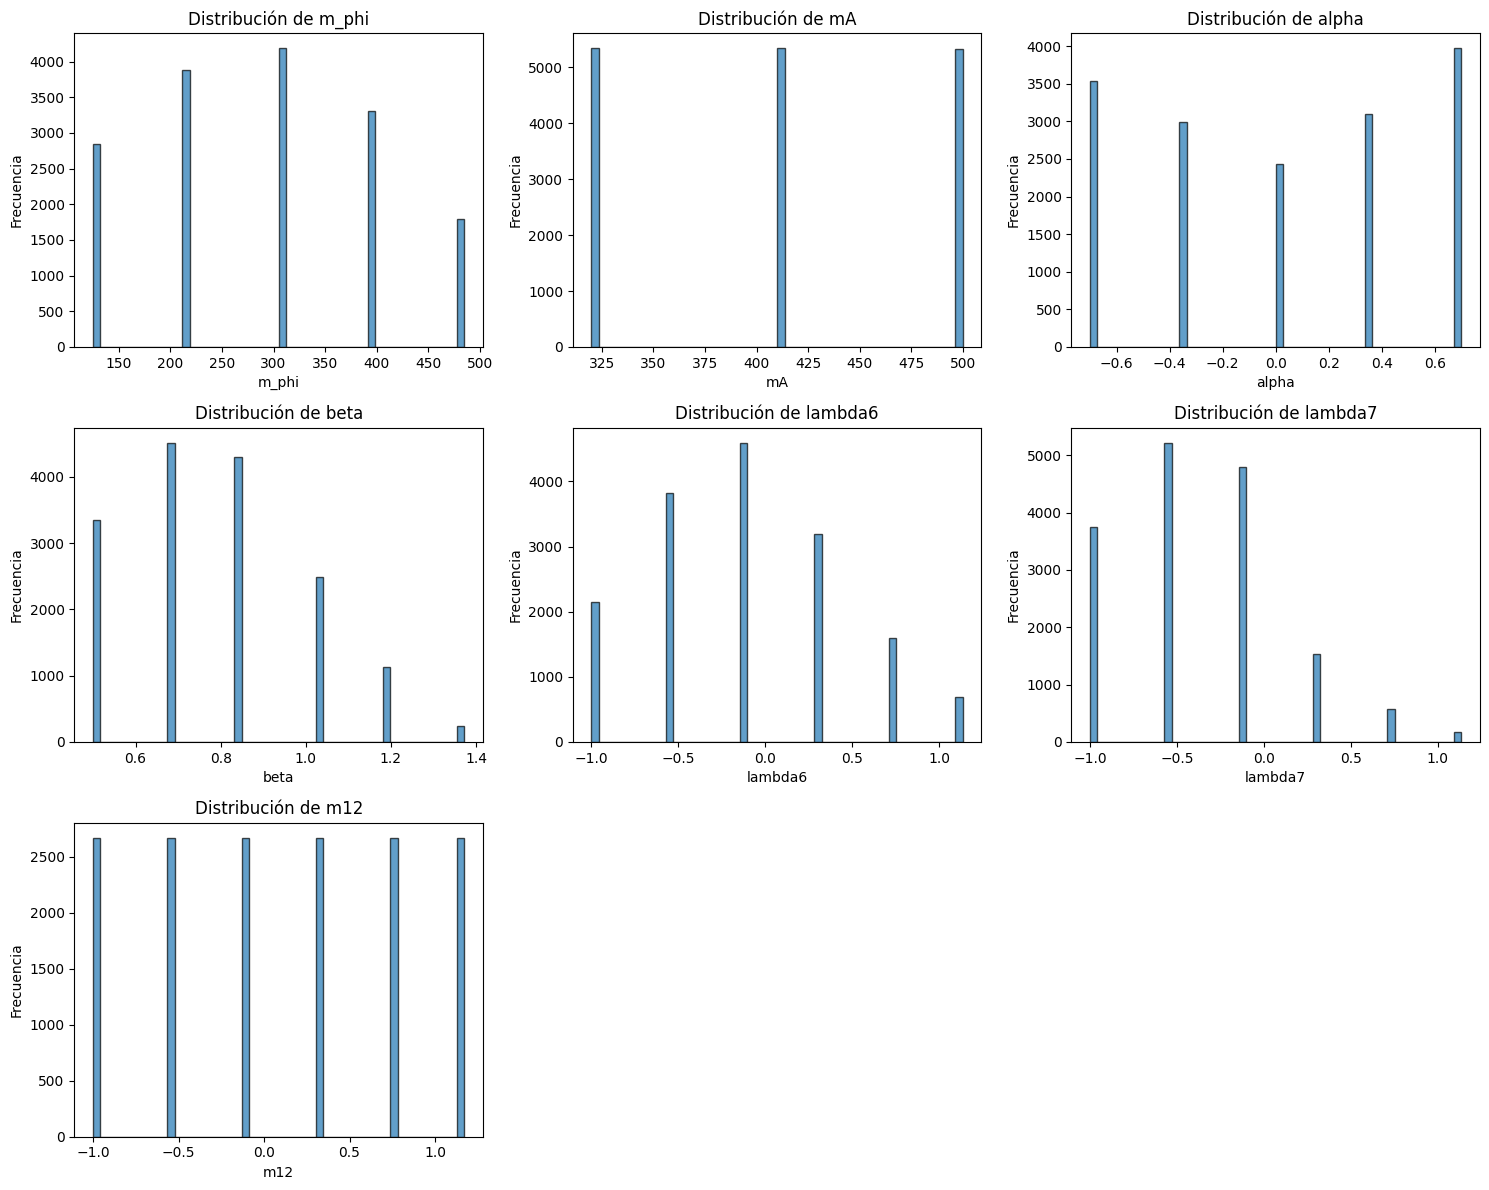

In [6]:
import random
# -------------------
# Parte 2: Muestreo aleatorio (Reservoir Sampling)
# Queremos obtener 'sample_size' puntos de forma aleatoria para visualización.
sample_size = 100000  # número de puntos deseados para la muestra
reservoir = []  # Lista que actuará como "reservorio"
total_count = 0  # Contador global de filas procesadas

print("\n--- Muestreo aleatorio mediante Reservoir Sampling ---")
for f in files:
    try:
        for chunk in pd.read_csv(f, chunksize=chunksize):
            # Filtrar filas que tengan definido el target
            chunk = chunk.dropna(subset=[target_col])
            if chunk.empty:
                continue
            # Mezclar aleatoriamente el chunk para romper el orden original
            chunk = chunk.sample(frac=1, random_state=42)
            # Convertir a lista de registros (solo columnas de parámetros)
            records = chunk[param_cols].to_dict('records')
            for record in records:
                total_count += 1
                if len(reservoir) < sample_size:
                    reservoir.append(record)
                else:
                    # Cada nueva fila tiene sample_size/total_count de probabilidad de reemplazar un elemento en el reservorio.
                    s = random.randint(0, total_count - 1)
                    if s < sample_size:
                        reservoir[s] = record
    except Exception as e:
        print(f"Error al procesar {f}: {e}")

if reservoir:
    sample_df = pd.DataFrame(reservoir)
    print(f"Muestra final para gráficos: {sample_df.shape[0]} registros.")
else:
    sample_df = pd.DataFrame(columns=param_cols)
    print("No se obtuvo ninguna muestra.")

# -------------------
# Parte 3: Graficar la distribución de los Branching Ratios
# En esta celda se asume que previamente se calcularon estadísticas globales
# sobre el target_col en otra parte del código (no se muestra aquí de nuevo).

# Para este ejemplo, creamos un histograma de los branching ratios de todos los archivos.
global_target_min = np.inf
global_target_max = -np.inf
target_total_valid = 0
target_hist_counts = None

# Primer pase para target_col: calcular min, max y contar los puntos válidos
for f in files:
    try:
        for chunk in pd.read_csv(f, chunksize=chunksize):
            if target_col not in chunk.columns:
                continue
            chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
            valid = chunk[target_col].dropna()
            if not valid.empty:
                target_total_valid += len(valid)
                curr_min = valid.min()
                curr_max = valid.max()
                global_target_min = min(global_target_min, curr_min)
                global_target_max = max(global_target_max, curr_max)
    except Exception as e:
        print(f"Error al procesar {f}: {e}")

print("\nEstadísticas globales del branching ratio:")
print("  Valor mínimo:", global_target_min)
print("  Valor máximo:", global_target_max)
print("  Total de valores válidos:", target_total_valid)
#print("  Total de valores NaN:", nan_counts[target_col])

# Segundo pase: Acumular histograma para target_col
bins = 50
bin_edges = np.linspace(global_target_min, global_target_max, bins + 1)
hist_counts = np.zeros(bins)

for f in files:
    try:
        for chunk in pd.read_csv(f, chunksize=chunksize):
            if target_col not in chunk.columns:
                continue
            chunk.replace([np.inf, -np.inf], np.nan, inplace=True)
            valid = chunk[target_col].dropna()
            if not valid.empty:
                counts, _ = np.histogram(valid, bins=bin_edges)
                hist_counts += counts
    except Exception as e:
        print(f"Error al procesar {f}: {e}")

plt.figure(figsize=(10, 6))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(bin_centers, hist_counts, width=(global_target_max - global_target_min)/bins, 
        edgecolor='k', alpha=0.7)
plt.xlabel("Branching Ratio")
plt.ylabel("Frecuencia")
plt.title("Histograma acumulado de Branching Ratio (procesado por chunks)")
plt.axvline(global_target_min, color='red', linestyle='dashed', linewidth=1, label=f"Min: {global_target_min:.2g}")
plt.axvline(global_target_max, color='green', linestyle='dashed', linewidth=1, label=f"Max: {global_target_max:.2g}")
plt.legend()
plt.show()

# -------------------
# Parte 4: Graficar la distribución de los 7 parámetros
fig, axs = plt.subplots(3, 3, figsize=(15, 12))
axs = axs.flatten()

for i, col in enumerate(param_cols):
    axs[i].hist(sample_df[col], bins=50, edgecolor='k', alpha=0.7)
    axs[i].set_title(f'Distribución de {col}')
    axs[i].set_xlabel(col)
    axs[i].set_ylabel("Frecuencia")

# Ocultar subplots sobrantes
for j in range(len(param_cols), len(axs)):
    axs[j].axis('off')

plt.tight_layout()